# ArXiv Articles: Computation and Language

In [1]:
# Load data from huggingface
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
abstracts = list(dataset["Abstracts"])
titles = list(dataset["Titles"])

# A Common Pipeline for Text Clustering

## Embedding Documents

In [2]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [3]:
# Check the dimensions of the resulting embeddings
embeddings.shape

(44949, 384)

## Reducing the Dimensionality of Embeddings

In [4]:
# python -m pip install umap-learn
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/opt/homebrew/Caskroom/miniforge/base/envs/qwen3.5-35b-a3b/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Cluster the Reduced Embeddings

In [5]:
# python -m pip install hdbscan
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

163

## Inspecting the Clusters

In [6]:
import numpy as np

# Print first three documents in cluster 0
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



In [7]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles # titles from step 1
df["cluster"] = [str(c) for c in clusters] # clusters from step 8

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

/opt/homebrew/Caskroom/miniforge/base/envs/qwen3.5-35b-a3b/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(np.float64(-8.814421391487121),
 np.float64(11.513033127784729),
 np.float64(-6.339562511444091),
 np.float64(11.35475263595581))

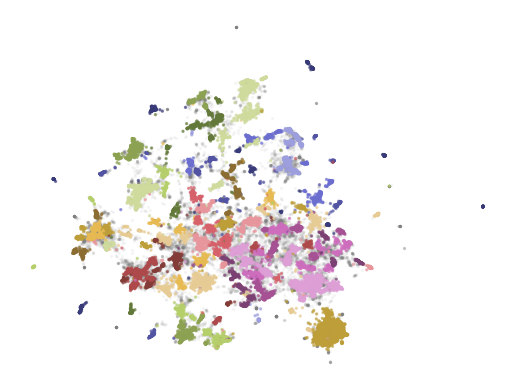

In [8]:
# python -m pip install matplotlib
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

# From Text Clustering to Topic Modeling

## BERTopic: A Modular Topic Modeling Framework

In [9]:
# python -m pip install bertopic
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2026-03-26 12:35:48,025 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-26 12:36:03,986 - BERTopic - Dimensionality - Completed ✓
2026-03-26 12:36:03,986 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-26 12:36:04,514 - BERTopic - Cluster - Completed ✓
2026-03-26 12:36:04,517 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-26 12:36:05,922 - BERTopic - Representation - Completed ✓


In [10]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15374,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...","[ Recently, pre-trained language models have ..."
1,0,2161,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...","[ Machine Speech Chain, which integrates both..."
2,1,1140,1_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, notes...",[ Biomedical Named Entity Recognition (NER) i...
3,2,957,2_translation_nmt_machine_neural,"[translation, nmt, machine, neural, bleu, engl...",[ Neural machine translation (NMT) becomes a ...
4,3,883,3_summarization_summaries_summary_abstractive,"[summarization, summaries, summary, abstractiv...",[ Abstractive summarization systems generally...
...,...,...,...,...,...
158,157,53,157_propaganda_techniques_news_subtask,"[propaganda, techniques, news, subtask, detect...",[ Propaganda aims at influencing people's min...
159,158,52,158_multimodal_sentiment_modality_fusion,"[multimodal, sentiment, modality, fusion, moda...",[ Multimodal machine learning is a core resea...
160,159,52,159_long_context_window_length,"[long, context, window, length, llms, memory, ...",[ Large Language Models (LLMs) are trained wi...
161,160,51,160_backdoor_attacks_attack_triggers,"[backdoor, attacks, attack, triggers, poisoned...",[ Deep neural networks (DNNs) and natural lan...


In [11]:
topic_model.get_topic(0)

[('speech', np.float64(0.028131020015129696)),
 ('asr', np.float64(0.01891528205562268)),
 ('recognition', np.float64(0.013433245105929163)),
 ('end', np.float64(0.010019065248040783)),
 ('acoustic', np.float64(0.009605211101031942)),
 ('speaker', np.float64(0.006868621388186095)),
 ('audio', np.float64(0.0068022598132775796)),
 ('wer', np.float64(0.0064842304398642974)),
 ('error', np.float64(0.006431170326836175)),
 ('automatic', np.float64(0.0060966913593059))]

In [12]:
topic_model.find_topics("topic modeling")

([22, -1, 54, 26, 1],
 [np.float64(0.9546464949334901),
  np.float64(0.9126112959301289),
  np.float64(0.9065286222757805),
  np.float64(0.9056327282094592),
  np.float64(0.9048597107345574)])

In [13]:
topic_model.get_topic(22)

[('topic', np.float64(0.06751807308270825)),
 ('topics', np.float64(0.03568417397215428)),
 ('lda', np.float64(0.016432863271491405)),
 ('documents', np.float64(0.013132340469121193)),
 ('latent', np.float64(0.013131897526580685)),
 ('document', np.float64(0.013048178877172993)),
 ('modeling', np.float64(0.011949331170826537)),
 ('dirichlet', np.float64(0.010050369193320342)),
 ('word', np.float64(0.008539810646702254)),
 ('allocation', np.float64(0.007880699367461363))]

In [14]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

22

### Visualization

In [15]:
import plotly
import plotly.io as pio
import notebook
import sys

print("plotly:", plotly.__version__)
print("renderer default:", pio.renderers.default)
print("python:", sys.version)
print("notebook:", notebook.__version__)
print(pio.renderers)

plotly: 6.6.0
renderer default: plotly_mimetype
python: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 17:06:14) [Clang 19.1.7 ]
notebook: 7.5.5
Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [16]:
import plotly.io as pio
pio.renderers.default = "iframe_connected"

In [17]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))

In [18]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()

In [19]:
# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

In [20]:
# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()

## Adding a Special Lego Block - Topic Representation Models

In [21]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [22]:
# def topic_differences(model, original_topics, nr_topics=5):
#     """Show the differences in topic representations between two models """
#     df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
#     for topic in range(nr_topics):

#         # Extract top 5 words per topic per model
#         og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
#         new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
#         df.loc[len(df)] = [topic, og_words, new_words]

#     return df

def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models."""
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words from the original representation
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])

        # BERTopic may pad generated topic labels with empty strings.
        # Remove empty placeholders so the Updated column stays readable.
        updated_terms = [term.strip() for term, _ in model.get_topic(topic) if str(term).strip()]
        new_words = " | ".join(updated_terms[:5])

        df.loc[len(df)] = [topic, og_words, new_words]

    return df

### KeyBERTInspired

In [23]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | phonetic | language | encoder | spoken
1,1,medical | clinical | biomedical | patient | notes,nlp | text | ehr | biomedical | clinical
2,2,translation | nmt | machine | neural | bleu,translating | translation | translate | transl...
3,3,summarization | summaries | summary | abstract...,summarization | summarizers | summaries | summ...
4,4,hate | offensive | speech | detection | toxic,hate | hateful | language | offensive | twitter


### Maximal Marginal Relevance

In [24]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | asr | error | automatic | model
1,1,medical | clinical | biomedical | patient | notes,clinical | biomedical | patient | domain | ext...
2,2,translation | nmt | machine | neural | bleu,translation | nmt | neural | bleu | parallel
3,3,summarization | summaries | summary | abstract...,summarization | extractive | documents | factu...
4,4,hate | offensive | speech | detection | toxic,offensive | toxic | media | hateful | platforms


## The Text Generation Lego Block - Topic Representation Models

### Flan-T5

In [25]:
# Original logic in the book, but it does not work 
# from transformers import pipeline
# from bertopic.representation import TextGeneration

# prompt = """I have a topic that contains the following documents:
# [DOCUMENTS]

# The topic is described by the following keywords: '[KEYWORDS]'.

# Based on the documents and keywords, what is this topic about?"""

# # Update our topic representations using Flan-T5
# generator = pipeline('text2text-generation', model='google/flan-t5-small')
# representation_model = TextGeneration(
#     generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
# )
# topic_model.update_topics(abstracts, representation_model=representation_model)

# # Show topic differences
# topic_differences(topic_model, original_topics)

In [26]:
# BERTopic expects a transformers Pipeline instance, but in transformers 5.3.0
# the old text2text-generation task is no longer registered. This wrapper keeps
# the Pipeline interface while delegating generation to Flan-T5 directly.
from transformers.pipelines.base import Pipeline

class FlanT5Pipeline(Pipeline):
    def __init__(self, model, tokenizer, max_new_tokens=32, device=None):
        super().__init__(model=model, tokenizer=tokenizer, task="text2text-generation", device=device)
        self.max_new_tokens = max_new_tokens

    def _sanitize_parameters(self, max_new_tokens=None, **kwargs):
        preprocess_kwargs = {}
        forward_kwargs = {}
        postprocess_kwargs = {}
        if max_new_tokens is not None:
            forward_kwargs["max_new_tokens"] = max_new_tokens
        return preprocess_kwargs, forward_kwargs, postprocess_kwargs

    def preprocess(self, inputs, **kwargs):
        return self.tokenizer(
            inputs,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )

    def _forward(self, model_inputs, max_new_tokens=None, **kwargs):
        model_inputs = {key: value.to(self.model.device) for key, value in model_inputs.items()}
        with torch.no_grad():
            output_ids = self.model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens or self.max_new_tokens,
            )
        return {"output_ids": output_ids}

    def postprocess(self, model_outputs, **kwargs):
        decoded = self.tokenizer.batch_decode(
            model_outputs["output_ids"],
            skip_special_tokens=True,
        )
        return [{"generated_text": text} for text in decoded]

In [27]:
from bertopic.representation import TextGeneration
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# Update our topic representations using Flan-T5
model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("mps")

generator = FlanT5Pipeline(model, tokenizer, max_new_tokens=32, device="mps")

representation_model = TextGeneration(
    generator,
    prompt=prompt,
    doc_length=50,
    tokenizer="whitespace",
    pipeline_kwargs={"max_new_tokens": 32},
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 163/163 [00:13<00:00, 12.33it/s]


,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,Speech-to-speech
1,1,medical | clinical | biomedical | patient | notes,Science/Tech
2,2,translation | nmt | machine | neural | bleu,Neural Machine Translation
3,3,summarization | summaries | summary | abstract...,Abstractive summarization
4,4,hate | offensive | speech | detection | toxic,Science/Tech


In [28]:
# # Release large objects before loading the local Qwen model
# import gc

# # Free the Flan-T5 objects created in the previous section.
# for name in ['generator', 'representation_model', 'model', 'tokenizer', 'FlanT5Pipeline']:
#     if name in globals():
#         del globals()[name]

# # These objects are no longer needed for the later Qwen labeling and datamap cells.
# # Keeping them around only increases unified-memory pressure.
# for name in ['embedding_model', 'embeddings', 'clusters_df', 'outliers_df', 'df', 'clusters', 'hdbscan_model']:
#     if name in globals():
#         del globals()[name]

# # BERTopic stores the embedding model as well; drop that reference after fitting.
# try:
#     if 'topic_model' in globals() and hasattr(topic_model, 'embedding_model'):
#         topic_model.embedding_model = None
# except Exception as e:
#     print(f'Skipping topic_model embedding cleanup: {e}')

# # Clear torch MPS memory if torch is available.
# try:
#     import torch
#     if hasattr(torch, 'mps') and hasattr(torch.mps, 'empty_cache'):
#         torch.mps.empty_cache()
# except Exception as e:
#     print(f'Skipping torch cache cleanup: {e}')

# collected = gc.collect()
# print(f'Pre-Qwen cleanup complete. Garbage collector reclaimed {collected} objects.')
# print('If the kernel still restarts here, run the Qwen section in a fresh kernel and skip the Flan section.')


### OpenAI

In [29]:
# import openai
# from bertopic.representation import OpenAI

# prompt = """
# I have a topic that contains the following documents:
# [DOCUMENTS]

# The topic is described by the following keywords: [KEYWORDS]

# Based on the information above, extract a short topic label in the following format:
# topic: <short topic label>
# """

# # Update our topic representations using GPT-3.5
# client = openai.OpenAI(api_key="YOUR_KEY_HERE")
# representation_model = OpenAI(
#     client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt
# )
# topic_model.update_topics(abstracts, representation_model=representation_model)

# # Show topic differences
# topic_differences(topic_model, original_topics)

### Qwen3.5-9B

In [30]:
from bertopic.representation._base import BaseRepresentation

class QwenRepresentation(BaseRepresentation):
    def __init__(self, model, tokenizer, prompt, nr_docs=4, diversity=None, doc_length=50, tokenizer_mode="whitespace", max_tokens=32):
        self.model = model
        self.tokenizer = tokenizer
        self.prompt = prompt
        self.nr_docs = nr_docs
        self.diversity = diversity
        self.doc_length = doc_length
        self.tokenizer_mode = tokenizer_mode
        self.max_tokens = max_tokens
        self.prompts_ = []
        validate_truncate_document_parameters(self.tokenizer_mode, self.doc_length)

    def extract_topics(self, topic_model, documents, c_tf_idf, topics):
        repr_docs_mappings, _, _, _ = topic_model._extract_representative_docs(
            c_tf_idf,
            documents,
            topics,
            500,
            self.nr_docs,
            self.diversity,
        )

        updated_topics = {}
        for topic, docs in tqdm(repr_docs_mappings.items(), desc="Generating topic labels"):
            truncated_docs = [
                truncate_document(topic_model, self.doc_length, self.tokenizer_mode, doc)
                for doc in docs
            ]
            prompt_text = self._create_prompt(truncated_docs, topic, topics)
            self.prompts_.append(prompt_text)

            messages = [
                {"role": "system", "content": "You extract short, precise topic labels."},
                {"role": "user", "content": prompt_text},
            ]
            chat_prompt = self.tokenizer.apply_chat_template(
                messages,
                add_generation_prompt=True,
                enable_thinking=False,
            )
            text = generate(
                self.model,
                self.tokenizer,
                prompt=chat_prompt,
                max_tokens=self.max_tokens,
                verbose=False,
            ).strip()

            label = self._extract_label(text)
            updated_topics[topic] = [(label, 1)]

        return updated_topics

    def _create_prompt(self, docs, topic, topics):
        keywords = ", ".join(next(zip(*topics[topic])))
        filled_prompt = self.prompt.replace("[KEYWORDS]", keywords)
        doc_block = "".join(f"- {doc}\n" for doc in docs)
        return filled_prompt.replace("[DOCUMENTS]", doc_block)

    @staticmethod
    def _extract_label(text):
        lines = [line.strip() for line in text.splitlines() if line.strip()]
        for line in lines:
            if line.lower().startswith("topic:"):
                return line.split(":", 1)[1].strip()
        return lines[0] if lines else "No label returned"

In [31]:
from bertopic.representation._utils import truncate_document, validate_truncate_document_parameters
from mlx_lm import load, generate
from tqdm.auto import tqdm

prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short topic label in the following format:
topic: <short topic label>
"""

# Load local Qwen model through MLX for topic labeling
local_model_name = "mlx-community/Qwen3.5-9B-MLX-4bit"
mlx_model, mlx_tokenizer = load(local_model_name)

representation_model = QwenRepresentation(
    mlx_model,
    mlx_tokenizer,
    prompt=prompt,
    nr_docs=4,
    diversity=None,
    doc_length=50,
    tokenizer_mode="whitespace",
    max_tokens=32,
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Generating topic labels:   0%|          | 0/163 [00:00<?, ?it/s]

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,Cross-modal speech-text alignment
1,1,medical | clinical | biomedical | patient | notes,Biomedical Named Entity Recognition
2,2,translation | nmt | machine | neural | bleu,Neural Machine Translation
3,3,summarization | summaries | summary | abstract...,Abstractive Summarization
4,4,hate | offensive | speech | detection | toxic,Multilingual Hate Speech Detection


In [32]:
# # Release Qwen resources after updating topic labels
# import gc

# for name in ['mlx_model', 'mlx_tokenizer', 'representation_model', 'QwenRepresentation', 'prompt', 'local_model_name']:
#     if name in globals():
#         del globals()[name]

# try:
#     import mlx.core as mx
#     if hasattr(mx, 'clear_cache'):
#         mx.clear_cache()
# except Exception as e:
#     print(f'Skipping MLX cache cleanup: {e}')

# collected = gc.collect()
# print(f'Post-Qwen cleanup complete. Garbage collector reclaimed {collected} objects.')


In [33]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15374,-1_Language Models and Task Adaptation,[Language Models and Task Adaptation],"[ Recently, pre-trained language models have ..."
1,0,2161,0_Cross-modal speech-text alignment,[Cross-modal speech-text alignment],"[ Machine Speech Chain, which integrates both..."
2,1,1140,1_Biomedical Named Entity Recognition,[Biomedical Named Entity Recognition],[ Biomedical Named Entity Recognition (NER) i...
3,2,957,2_Neural Machine Translation,[Neural Machine Translation],[ Neural machine translation (NMT) becomes a ...
4,3,883,3_Abstractive Summarization,[Abstractive Summarization],[ Abstractive summarization systems generally...
...,...,...,...,...,...
158,157,53,157_Propaganda Detection Techniques,[Propaganda Detection Techniques],[ Propaganda aims at influencing people's min...
159,158,52,158_Multimodal Sentiment Analysis,[Multimodal Sentiment Analysis],[ Multimodal machine learning is a core resea...
160,159,52,159_Long Context LLMs,[Long Context LLMs],[ Large Language Models (LLMs) are trained wi...
161,160,51,160_NLP Backdoor Attacks,[NLP Backdoor Attacks],[ Deep neural networks (DNNs) and natural lan...


In [34]:
topic_model.get_topic(0)

[('Cross-modal speech-text alignment', 1)]

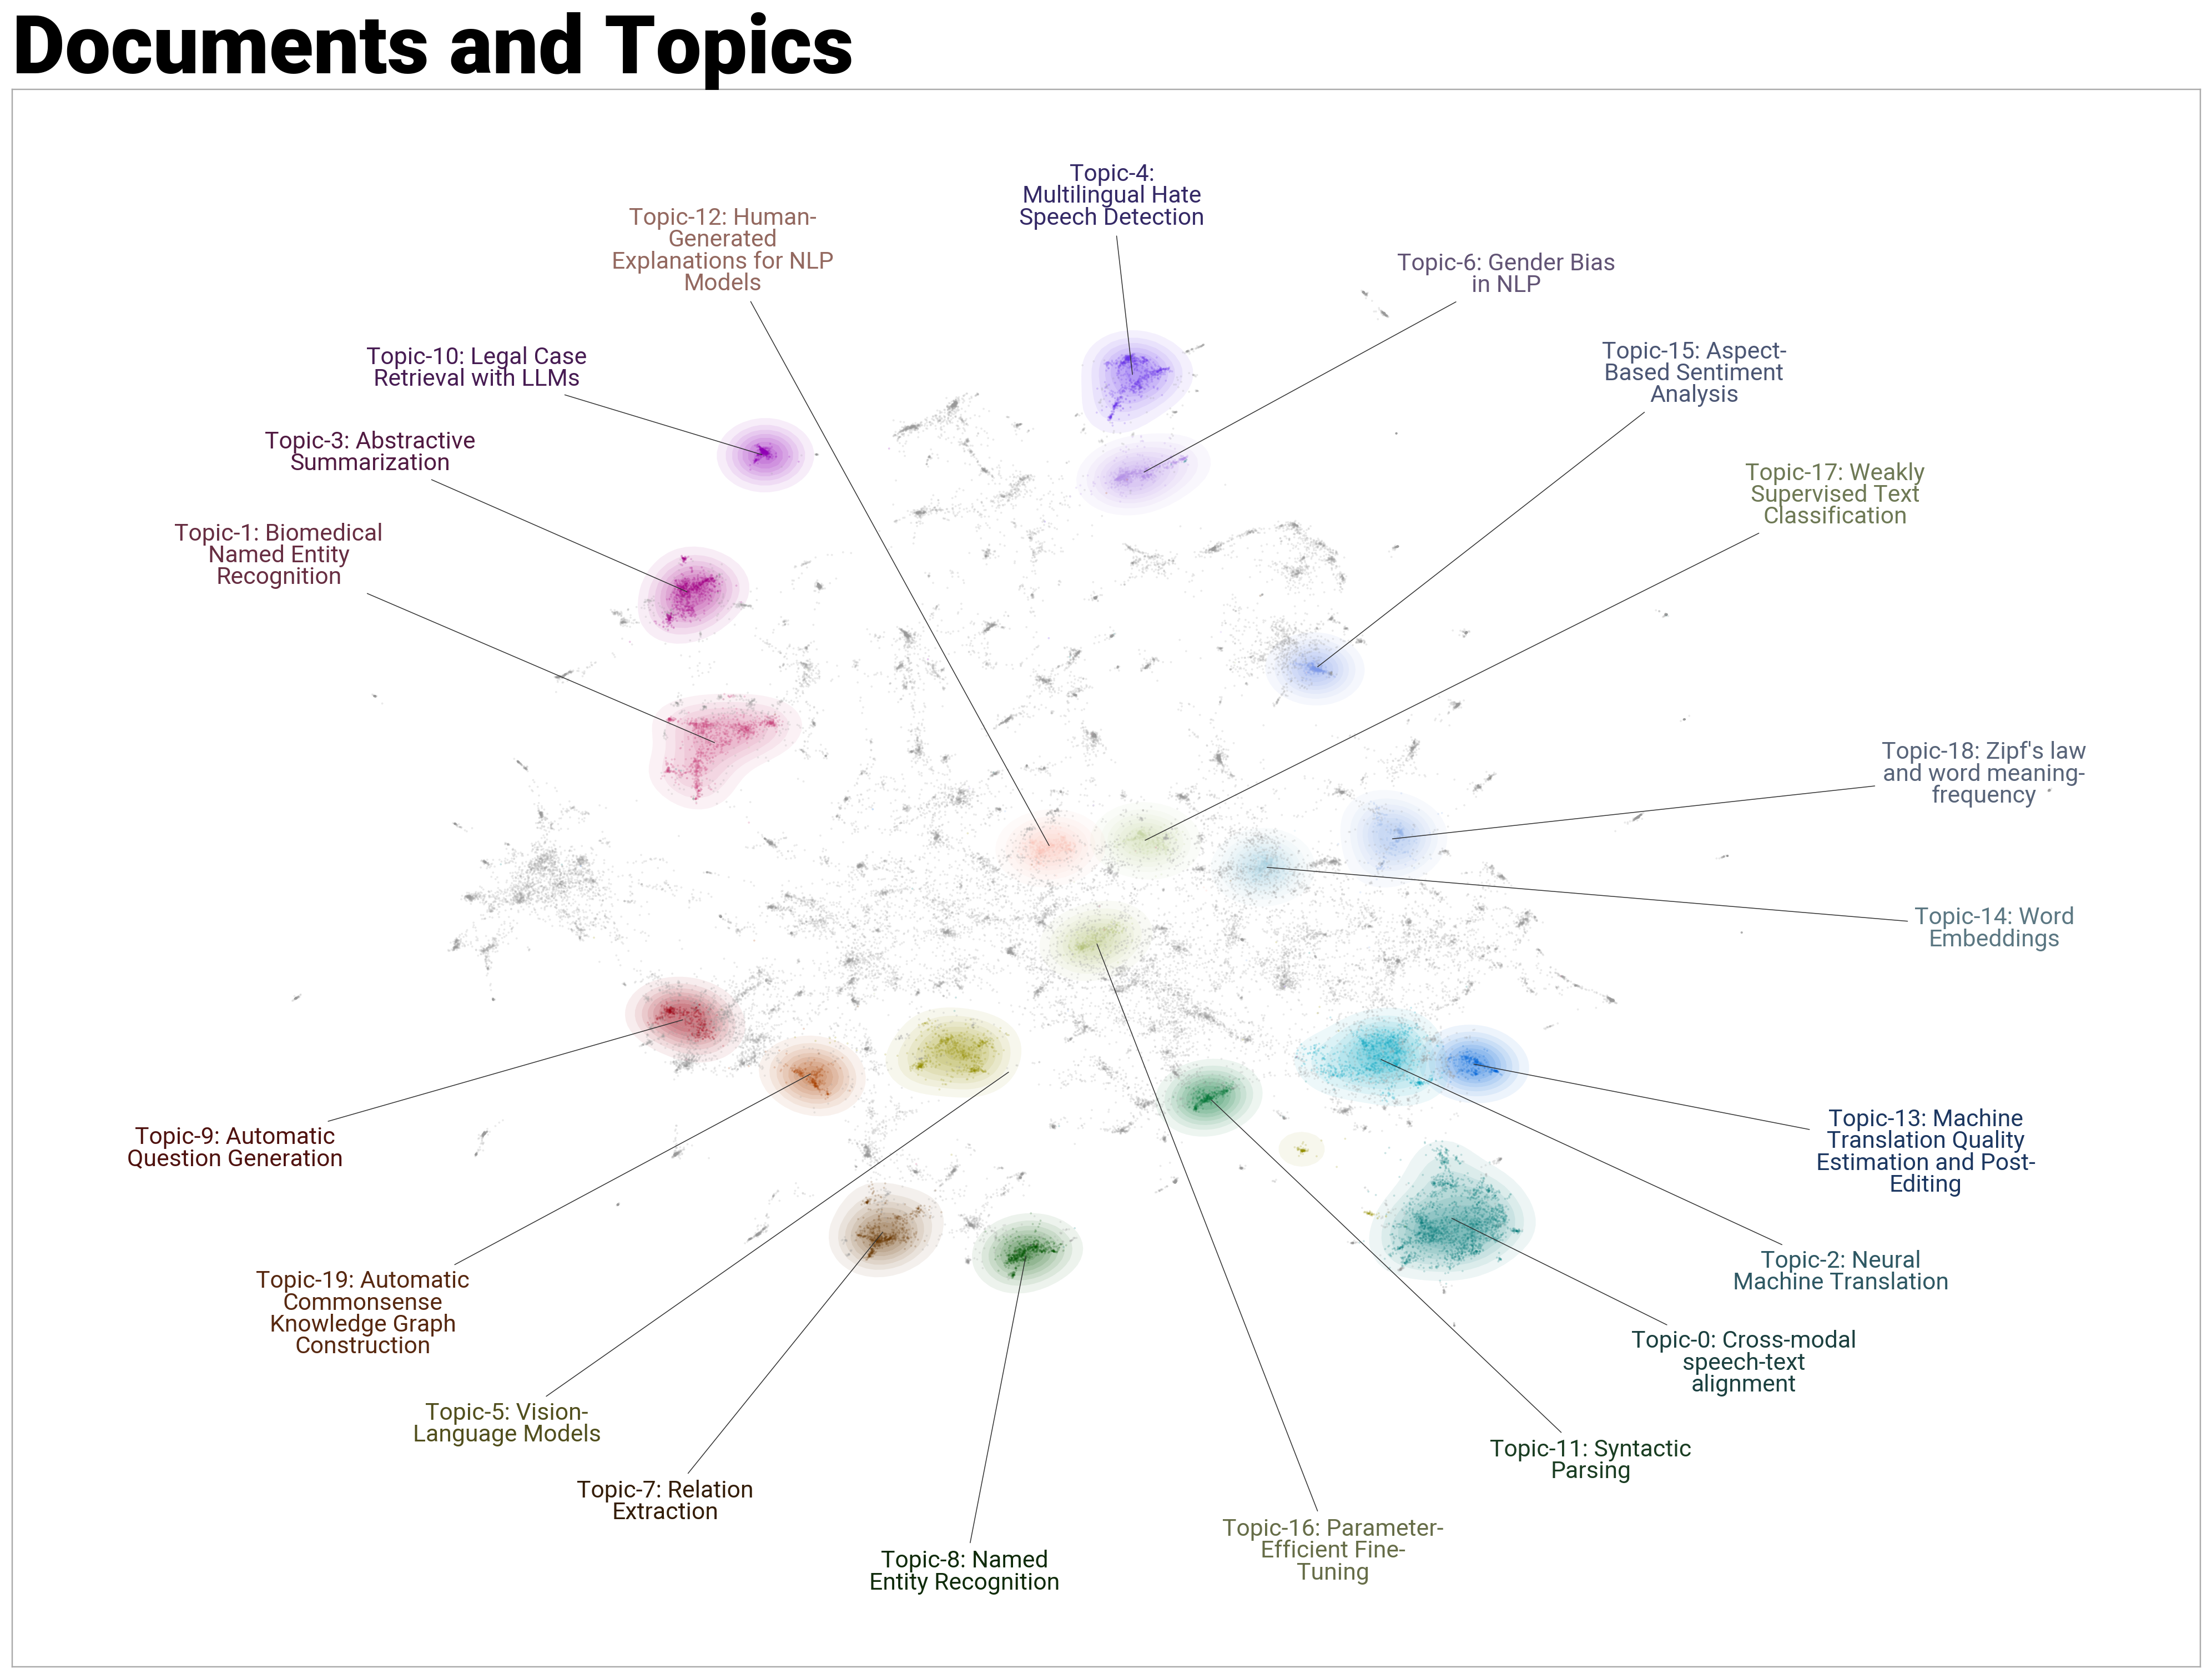

In [35]:
import datamapplot

# BERTopic's visualize_document_datamap does not accept label_font_size or
# label_wrap_width as top-level arguments in this version. We also avoid
# use_medoids here because it triggers a much heavier numba-based medoid
# computation path and is the most likely cause of the kernel restarts.
fig = topic_model.visualize_document_datamap(
    titles,
    topics=list(range(20)),
    reduced_embeddings=reduced_embeddings,
    width=1800,
    height=1300,
    topic_prefix=True,
    datamap_kwds={
        'label_font_size': 14,
        'label_wrap_width': 20,
    },
)
fig.set_dpi(220)
fig.set_size_inches(18, 13)
fig.savefig('datamapplot.png', dpi=300, bbox_inches='tight')

## Topic Represention Visualization - Word Cloud

In [36]:
topic_model.update_topics(abstracts, top_n_words=500)

2026-03-26 12:38:44,894 - BERTopic - WARNING: Note that extracting more than 100 words from a sparse can slow down computation quite a bit.


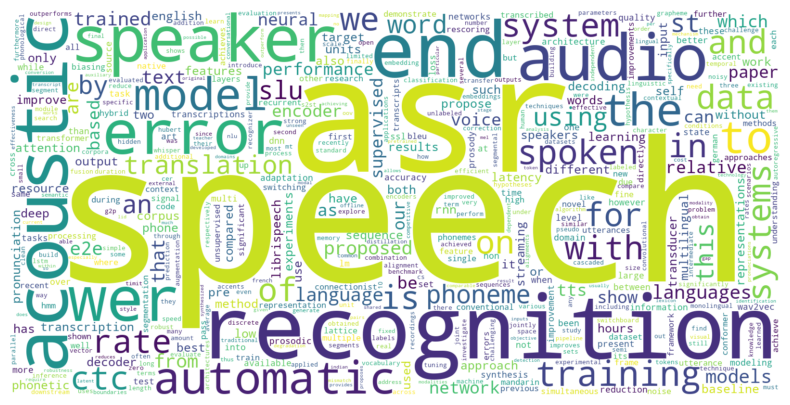

In [37]:
# python -m pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    plt.figure(figsize=(10,5))
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000, width=1600, height=800)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud of topic 0
create_wordcloud(topic_model, topic=0)